In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import random
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List
from sklearn.preprocessing import MinMaxScaler

In [17]:
pd.read_csv('../data/final_hess.csv')

,Timestamp,Solar_Power_kW,Wind_Power_kW,Grid_Power_kW,Battery_SoC_%,SC_Charge_kW_x,Hydrogen_Production_kg/h,Load_Demand_kW,Power_Supplied_kW,Power_Loss_kW,...,Grid_Status,SC_Energy_kWh_raw,Optimization_Level,day_name,month_name,Combined_Renewable_kW,Power_Deficit_kW,Load_Demand_Rate_of_Change,Solar_Power_Rate_of_Change,Wind_Power_Rate_of_Change
0,2024-04-01 00:00:00,18.727006,7.405317,8.925585,73.816240,5.719959,1.968178,62.412848,62.218850,0.193997,...,1,0.000000,High Efficiency,Monday,April,26.132323,36.280525,0.000000,0.000000,0.000000
1,2024-04-01 01:00:00,47.535715,21.676038,8.704682,83.734512,8.054323,2.367178,38.619318,37.685455,0.933863,...,1,0.040529,High Efficiency,Monday,April,69.211753,-30.592435,23.793530,28.808709,14.270721
2,2024-04-01 02:00:00,36.599697,34.917833,18.593819,40.037432,7.601609,4.272737,73.619728,69.463499,4.156229,...,1,0.044568,Moderate Efficiency,Monday,April,71.517531,2.102198,35.000410,10.936018,13.241796
3,2024-04-01 03:00:00,29.932924,29.288995,8.743193,69.989928,1.538999,1.700022,60.655812,56.821970,3.833842,...,1,0.000000,Moderate Efficiency,Monday,April,59.221920,1.433892,12.963916,6.666773,5.628838
4,2024-04-01 04:00:00,7.800932,32.262446,9.079246,65.739679,1.492495,4.348248,37.860194,36.106981,1.753213,...,1,0.000000,High Efficiency,Monday,April,40.063378,-2.203184,22.795618,22.131992,2.973450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-05-12 11:00:00,4.579104,26.278206,17.979436,55.368563,8.973973,3.422177,58.986856,57.621058,1.365798,...,1,17.139063,High Efficiency,Sunday,May,30.857310,28.129546,17.438532,13.469591,3.776797
996,2024-05-12 12:00:00,45.865679,38.264585,7.359098,46.752094,1.193810,2.516102,63.351843,62.304247,1.047596,...,1,17.230988,High Efficiency,Sunday,May,84.130264,-20.778421,4.364987,41.286575,11.986379
997,2024-05-12 13:00:00,6.840932,2.758321,9.646818,51.565785,3.278428,3.825744,75.578844,73.302201,2.276644,...,1,17.216940,High Efficiency,Sunday,May,9.599252,65.979592,12.227002,39.024747,35.506264
998,2024-05-12 14:00:00,47.511868,2.282189,9.350683,62.395247,8.157454,2.426453,47.281008,42.738821,4.542188,...,1,17.189966,Moderate Efficiency,Sunday,May,49.794057,-2.513048,28.297836,40.670936,0.476132


In [3]:
df = pd.read_csv('../data/final_hess.csv')
df = pd.get_dummies(df, columns=['Optimization_Level'], prefix='opt_level',dtype=int)
df = df.drop(['day_name','month_name'],axis=1)

# Preprocessing steps

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['sin_hour'] = np.sin(2 * np.pi * df['hour']/24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour']/24)


# Define the columns to be scaled for the observation space
# Note: SC_Energy_kWh_raw is also a SOC value, not part of the features
obs_cols_to_scale = ['Combined_Renewable_kW', 'Load_Demand_kW', 'Electricity_Price_USDperkWh', 'sin_hour', 'cos_hour']


# Initialize and fit the scaler
scaler = MinMaxScaler()
df[obs_cols_to_scale] = scaler.fit_transform(df[obs_cols_to_scale])

# Save the preprocessed DataFrame to a new file (optional but good practice)
df.to_csv('preprocessed_hess.csv', index=False)

Episode 0001 | Return -1298.87 | Loss   0.0000 | Epsilon 1.000
New best model saved with return: -1298.87
Episode 0002 | Return -1360.36 | Loss   0.2259 | Epsilon 1.000
Episode 0003 | Return -1309.57 | Loss   0.0810 | Epsilon 0.981
Episode 0004 | Return -1328.82 | Loss   0.0620 | Epsilon 0.962
Episode 0005 | Return -1279.03 | Loss   0.0645 | Epsilon 0.943
New best model saved with return: -1279.03
Episode 0006 | Return -1284.52 | Loss   0.0634 | Epsilon 0.924
Episode 0007 | Return -1207.90 | Loss   0.0555 | Epsilon 0.905
New best model saved with return: -1207.90
Episode 0008 | Return -1187.97 | Loss   0.0651 | Epsilon 0.886
New best model saved with return: -1187.97
Episode 0009 | Return -1108.24 | Loss   0.0807 | Epsilon 0.867
New best model saved with return: -1108.24
Episode 0010 | Return -1127.02 | Loss   0.0807 | Epsilon 0.848
Episode 0011 | Return -1188.99 | Loss   0.1014 | Epsilon 0.829
Episode 0012 | Return -1082.12 | Loss   0.0945 | Epsilon 0.810
New best model saved with ret

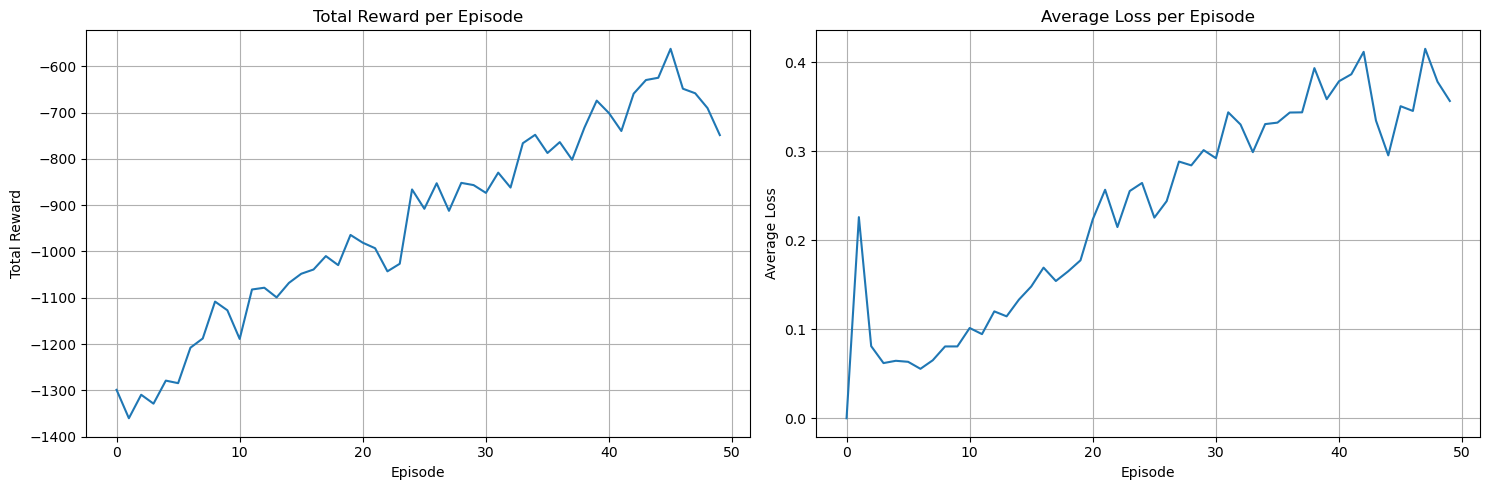

In [5]:
data_path = 'preprocessed_hess.csv'
episodes = 50
save_model_path = "dqn_jupyter_model.pt"

@dataclass
class EnvConfig:
    col_renewable_kw: str = "Combined_Renewable_kW"
    col_load_kw: str = "Load_Demand_kW"
    col_price: str = "Electricity_Price_USDperkWh"
    col_batt_soc: str = "Battery_SoC_%"
    col_sc_energy: str = "SC_Energy_kWh_raw"
    
    
    batt_capacity_kwh: float = 100.0
    batt_max_c_rate: float = 0.5
    batt_eta_charge: float = 0.96
    batt_eta_discharge: float = 0.96
    batt_soc_min: float = 0.1
    batt_soc_max: float = 0.9
    batt_throughput_cost: float = 0.02
    
    sc_capacity_kwh: float = 5.0
    sc_max_c_rate: float = 10.0
    sc_eta_charge: float = 0.98
    sc_eta_discharge: float = 0.98
    sc_soc_min: float = 0.05
    sc_soc_max: float = 0.95
    sc_throughput_cost: float = 0.005
    
    unmet_load_penalty: float = 2.0
    overflow_penalty: float = 2.0
    soc_violation_penalty: float = 5.0

@dataclass
class TrainConfig:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    gamma: float = 0.99
    lr: float = 1e-3
    batch_size: int = 128
    replay_size: int = 50_000
    start_steps: int = 2_000
    train_after: int = 1_000
    train_freq: int = 1
    target_sync: int = 1_000
    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay_steps: int = 50_000
    max_grad_norm: float = 5.0


class HESSMicrogridEnv(gym.Env):
    def __init__(self, df: pd.DataFrame, cfg: EnvConfig):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.T = len(self.df)
        self.ep_len = len(self.df)

        self.action_list: List[Tuple[float, float]] = []
        batt_p_max = self.cfg.batt_capacity_kwh * self.cfg.batt_max_c_rate
        sc_p_max = self.cfg.sc_capacity_kwh * self.cfg.sc_max_c_rate
        for pb in np.round(np.linspace(-batt_p_max, batt_p_max, 5), 3):
            for ps in np.round(np.linspace(-sc_p_max, sc_p_max, 5), 3):
                self.action_list.append((float(pb), float(ps)))
        
        self.action_space = spaces.Discrete(len(self.action_list))
        # The observation space now has 7 dimensions with the cyclical features
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)
        
        self.ptr = 0
        self.t = 0
        self.batt_soc = None
        self.sc_soc = None
    
    def _obs(self) -> np.ndarray:
        row = self.df.loc[self.ptr + self.t]    
        obs = np.array([
            row[self.cfg.col_renewable_kw] / self.cfg.batt_capacity_kwh,
            row[self.cfg.col_load_kw] / self.cfg.batt_capacity_kwh,
            row[self.cfg.col_price],
            float(self.batt_soc),
            float(self.sc_soc),
            row['sin_hour'],
            row['cos_hour']
        ], dtype=np.float32)
        return obs
        
    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        self.ptr = 0
        self.t = 0
        self.batt_soc = 0.5
        self.sc_soc = 0.5
        return self._obs(), {}
    
    def step(self, action_idx: int):
        p_batt_kw, p_sc_kw = self.action_list[action_idx]
        dt = 1.0
        
        # Calculate energy flow and SOC updates
        batt_e_out = max(0.0, p_batt_kw) * dt * self.cfg.batt_eta_discharge
        batt_e_in = max(0.0, -p_batt_kw) * dt / max(1e-6, self.cfg.batt_eta_charge)
        sc_e_out = max(0.0, p_sc_kw) * dt * self.cfg.sc_eta_discharge
        sc_e_in = max(0.0, -p_sc_kw) * dt / max(1e-6, self.cfg.sc_eta_charge)
        
        batt_energy_next = self.batt_soc * self.cfg.batt_capacity_kwh - batt_e_out + batt_e_in
        sc_energy_next = self.sc_soc * self.cfg.sc_capacity_kwh - sc_e_out + sc_e_in
        
        batt_soc_next = batt_energy_next / self.cfg.batt_capacity_kwh
        sc_soc_next = sc_energy_next / self.cfg.sc_capacity_kwh
        
        # Handle SOC violations
        soc_violation = 0.0
        if batt_soc_next < self.cfg.batt_soc_min:
            soc_violation += (self.cfg.batt_soc_min - batt_soc_next)
            batt_soc_next = self.cfg.batt_soc_min
        if batt_soc_next > self.cfg.batt_soc_max:
            soc_violation += (batt_soc_next - self.cfg.batt_soc_max)
            batt_soc_next = self.cfg.batt_soc_max
            
        # Calculate reward
        row = self.df.loc[self.ptr + self.t]
        renewable = row[self.cfg.col_renewable_kw]
        load = row[self.cfg.col_load_kw]
        price = row[self.cfg.col_price]

        grid_import_kw = max(0, load - renewable - max(0, p_batt_kw) - max(0, p_sc_kw))
        energy_cost = grid_import_kw * dt * price
        
        batt_throughput = batt_e_out + batt_e_in
        sc_throughput = sc_e_out + sc_e_in
        degr_cost = batt_throughput * self.cfg.batt_throughput_cost + sc_throughput * self.cfg.sc_throughput_cost
        
        penalty = self.cfg.soc_violation_penalty * soc_violation
        
        reward = -(energy_cost + degr_cost + penalty)

        self.batt_soc = batt_soc_next
        self.sc_soc = sc_soc_next
        self.t += 1
        terminated = (self.t >= self.ep_len)
        truncated = False
        
        next_obs = self._obs() if not terminated else np.zeros(7)
        info = {}
        
        return next_obs, reward, terminated, truncated, info

class QNetwork(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_sizes=(128, 128)):
        super().__init__()
        layers = []
        last = obs_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers += [nn.Linear(last, act_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity: int, obs_dim: int):
        self.capacity = capacity
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity,), dtype=np.int64)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)
        self.idx = 0
        self.full = False

    def push(self, o, a, r, no, d):
        self.obs[self.idx] = o
        self.actions[self.idx] = a
        self.rewards[self.idx] = r
        self.next_obs[self.idx] = no
        self.dones[self.idx] = d
        self.idx = (self.idx + 1) % self.capacity
        self.full = self.full or self.idx == 0

    def sample(self, batch_size: int):
        max_idx = self.capacity if self.full else self.idx
        idxs = np.random.randint(0, max_idx, size=batch_size)
        return (
            torch.from_numpy(self.obs[idxs]),
            torch.from_numpy(self.actions[idxs]),
            torch.from_numpy(self.rewards[idxs]),
            torch.from_numpy(self.next_obs[idxs]),
            torch.from_numpy(self.dones[idxs]),
        )



class DQNAgent:
    def __init__(self, obs_dim: int, act_dim: int, tcfg: TrainConfig):
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.tcfg = tcfg
        self.q = QNetwork(obs_dim, act_dim).to(tcfg.device)
        self.q_target = QNetwork(obs_dim, act_dim).to(tcfg.device)
        self.q_target.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=tcfg.lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.step_count = 0
        self.eps = tcfg.eps_start

    def act(self, obs: np.ndarray) -> int:
        self.step_count += 1
        decay = max(0.0, min(1.0, self.step_count / self.tcfg.eps_decay_steps))
        self.eps = self.tcfg.eps_start + decay * (self.tcfg.eps_end - self.tcfg.eps_start)
        if random.random() < self.eps:
            return random.randrange(self.act_dim)
        with torch.no_grad():
            o = torch.tensor(obs, dtype=torch.float32, device=self.tcfg.device).unsqueeze(0)
            qvals = self.q(o)
            return int(torch.argmax(qvals, dim=1).item())

    def update(self, buf: ReplayBuffer, batch_size: int) -> float:
        o, a, r, no, d = buf.sample(batch_size)
        o = o.to(self.tcfg.device)
        a = a.to(self.tcfg.device)
        r = r.to(self.tcfg.device)
        no = no.to(self.tcfg.device)
        d = d.to(self.tcfg.device)

        qvals = self.q(o).gather(1, a.view(-1, 1)).squeeze(1)
        with torch.no_grad():
            next_q = self.q_target(no).max(dim=1)[0]
            target = r + (1.0 - d) * self.tcfg.gamma * next_q
        loss = self.loss_fn(qvals, target)
        self.opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), self.tcfg.max_grad_norm)
        self.opt.step()
        return float(loss.item())

    def sync_target(self):
        self.q_target.load_state_dict(self.q.state_dict())

def train_and_plot(df: pd.DataFrame, episodes: int, save_path: str = "dqn_jupyter_model.pt"):
    
    
    ecfg = EnvConfig()
    tcfg = TrainConfig()

    env = HESSMicrogridEnv(df, ecfg)
    obs_dim = 7  # The observation space now has 7 dimensions
    act_dim = env.action_space.n
    agent = DQNAgent(obs_dim, act_dim, tcfg)
    buf = ReplayBuffer(tcfg.replay_size, obs_dim)

    best_eval = -np.inf
    total_steps = 0
    ep_rewards = []
    ep_losses = []

    for ep in range(1, episodes + 1):
        obs, _ = env.reset()
        ep_ret = 0.0
        ep_loss_sum = 0.0
        done = False
        term = False
        trunc = False

        while not (term or trunc):
            if total_steps < tcfg.start_steps:
                action = env.action_space.sample()
            else:
                action = agent.act(obs)
            
            next_obs, reward, term, trunc, info = env.step(action)
            done = term or trunc
            buf.push(obs, action, reward, next_obs, float(done))

            obs = next_obs
            ep_ret += reward
            total_steps += 1

            if total_steps > tcfg.train_after and total_steps % tcfg.train_freq == 0:
                loss = agent.update(buf, tcfg.batch_size)
                ep_loss_sum += loss
            
            if total_steps % tcfg.target_sync == 0:
                agent.sync_target()

        ep_rewards.append(ep_ret)
        ep_losses.append(ep_loss_sum / env.ep_len)

        print(f"Episode {ep:04d} | Return {ep_ret:8.2f} | Loss {ep_losses[-1]:8.4f} | Epsilon {agent.eps:.3f}")

        if ep_ret > best_eval:
            best_eval = ep_ret
            torch.save(agent.q.state_dict(), save_path)
            print(f"New best model saved with return: {best_eval:.2f}")

    print("Training complete.")
    
    # Plotting the metrics
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(ep_rewards)
    plt.title('Total Reward per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(ep_losses)
    plt.title('Average Loss per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Average Loss')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Run the training
df = pd.read_csv('preprocessed_hess.csv')
train_and_plot(df, episodes)

# Model Evaluation

Evaluation completed. Total reward = -1312.89
Saved evaluation results to results_eval/dqn_eval_results.csv


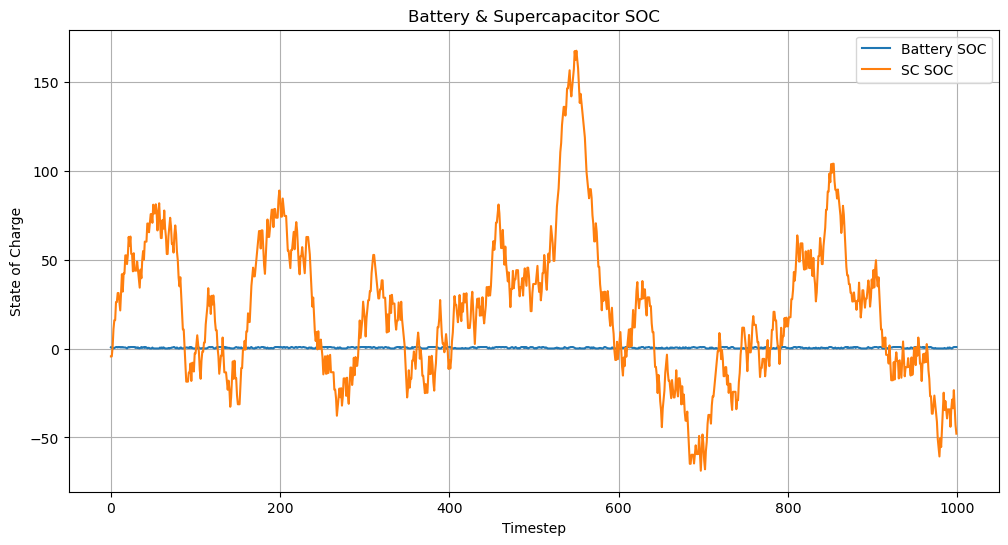

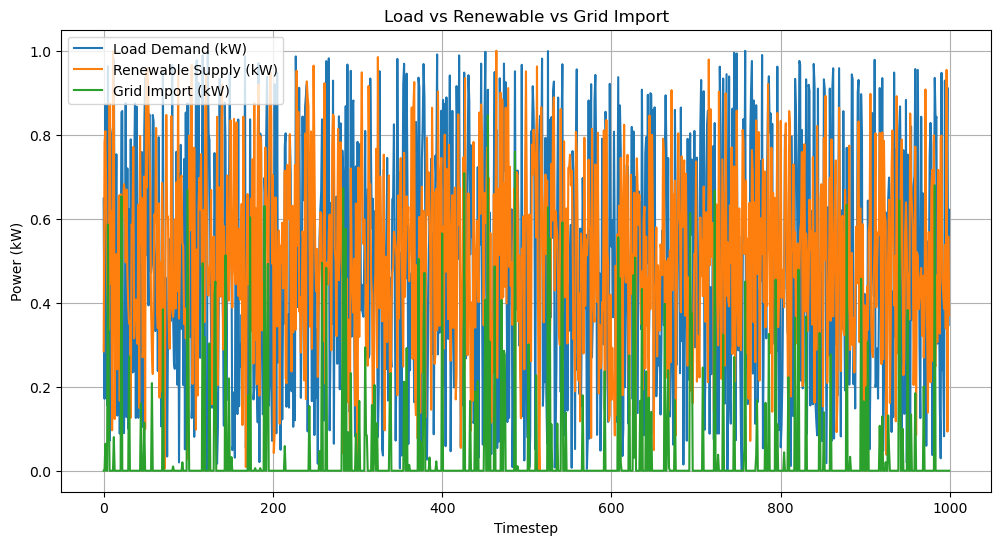

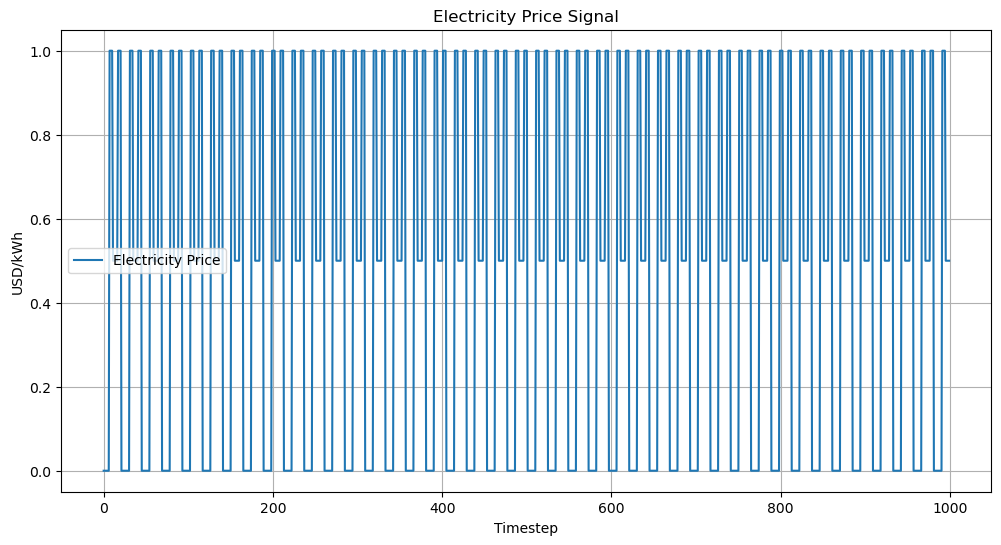

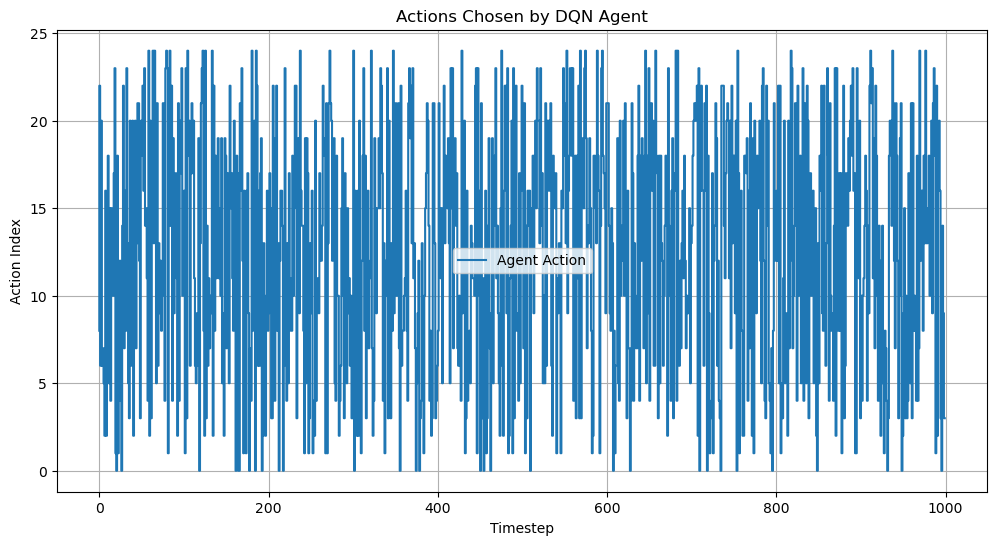

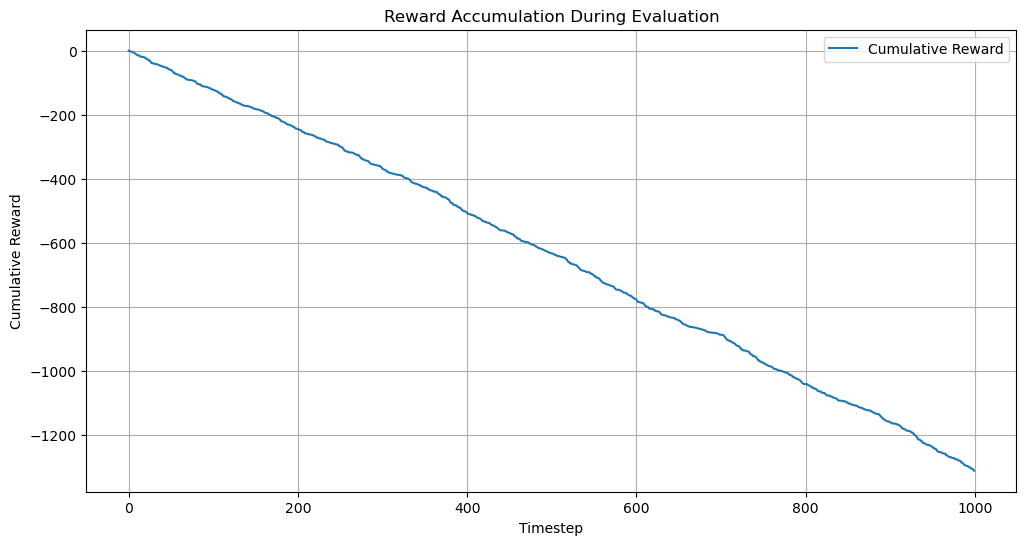

In [7]:
import os
def evaluate_and_plot(df, model_path="dqn_jupyter_model.pt", save_dir="results_eval"):
    os.makedirs(save_dir, exist_ok=True)

    ecfg = EnvConfig()
    tcfg = TrainConfig()

    env = HESSMicrogridEnv(df, ecfg)
    obs_dim = 7
    act_dim = env.action_space.n
    agent = DQNAgent(obs_dim, act_dim, tcfg)

    # Load trained weights
    agent.q.load_state_dict(torch.load(model_path, map_location=tcfg.device))
    agent.q.eval()

    # Storage for episode data
    batt_socs, sc_socs, loads, renews, prices, actions, rewards, grid_imports = [], [], [], [], [], [], [], []

    obs, _ = env.reset()
    done, term, trunc = False, False, False
    total_reward = 0.0

    while not (term or trunc):
        action = agent.act(obs)
        next_obs, reward, term, trunc, info = env.step(action)

        # Log values
        row = df.loc[env.ptr + env.t - 1]
        batt_socs.append(env.batt_soc)
        sc_socs.append(env.sc_soc)
        loads.append(row[ecfg.col_load_kw])
        renews.append(row[ecfg.col_renewable_kw])
        prices.append(row[ecfg.col_price])
        actions.append(action)
        rewards.append(reward)

        # Recompute grid import for logging
        p_batt_kw, p_sc_kw = env.action_list[action]
        grid_import_kw = max(0, row[ecfg.col_load_kw] - row[ecfg.col_renewable_kw] - max(0, p_batt_kw) - max(0, p_sc_kw))
        grid_imports.append(grid_import_kw)

        total_reward += reward
        obs = next_obs

    print(f"Evaluation completed. Total reward = {total_reward:.2f}")
    # Save evaluation results for comparison
    eval_results = pd.DataFrame({
        "Battery_SOC_kWh": batt_socs,
        "SC_SOC_kWh": sc_socs,
        "Grid_Import_kW": grid_imports,
        "Reward": rewards,
        "Load_kW": loads,
        "Renewable_kW": renews,
        "Price": prices,
        "Action": actions
    })
    eval_results.to_csv(f"{save_dir}/dqn_eval_results.csv", index=False)
    print(f"Saved evaluation results to {save_dir}/dqn_eval_results.csv")


    # =======================
    # Plotting
    # =======================
    timesteps = range(len(batt_socs))

    plt.figure(figsize=(12,6))
    plt.plot(timesteps, batt_socs, label="Battery SOC")
    plt.plot(timesteps, sc_socs, label="SC SOC")
    plt.xlabel("Timestep")
    plt.ylabel("State of Charge")
    plt.title("Battery & Supercapacitor SOC")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{save_dir}/soc_curves.png")
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(timesteps, loads, label="Load Demand (kW)")
    plt.plot(timesteps, renews, label="Renewable Supply (kW)")
    plt.plot(timesteps, grid_imports, label="Grid Import (kW)")
    plt.xlabel("Timestep")
    plt.ylabel("Power (kW)")
    plt.title("Load vs Renewable vs Grid Import")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{save_dir}/supply_demand.png")
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(timesteps, prices, label="Electricity Price")
    plt.xlabel("Timestep")
    plt.ylabel("USD/kWh")
    plt.title("Electricity Price Signal")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{save_dir}/prices.png")
    plt.show()

    plt.figure(figsize=(12,6))
    plt.step(timesteps, actions, label="Agent Action")
    plt.xlabel("Timestep")
    plt.ylabel("Action Index")
    plt.title("Actions Chosen by DQN Agent")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{save_dir}/actions.png")
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(timesteps, np.cumsum(rewards), label="Cumulative Reward")
    plt.xlabel("Timestep")
    plt.ylabel("Cumulative Reward")
    plt.title("Reward Accumulation During Evaluation")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{save_dir}/rewards.png")
    plt.show()
evaluate_and_plot(df, model_path="dqn_jupyter_model.pt", save_dir="results_eval")

## Rule Based

In [9]:
df.head()

,Timestamp,Solar_Power_kW,Wind_Power_kW,Grid_Power_kW,Battery_SoC_%,SC_Charge_kW_x,Hydrogen_Production_kg/h,Load_Demand_kW,Power_Supplied_kW,Power_Loss_kW,...,Combined_Renewable_kW,Power_Deficit_kW,Load_Demand_Rate_of_Change,Solar_Power_Rate_of_Change,Wind_Power_Rate_of_Change,opt_level_High Efficiency,opt_level_Low Efficiency,opt_level_Moderate Efficiency,sin_hour,cos_hour
0,2024-04-01 00:00:00,18.727006,7.405317,8.925585,73.816240,5.719959,1.968178,0.648104,62.218850,0.193997,...,0.284191,36.280525,0.000000,0.000000,0.000000,1,0,0,0.500000,1.000000
1,2024-04-01 01:00:00,47.535715,21.676038,8.704682,83.734512,8.054323,2.367178,0.171295,37.685455,0.933863,...,0.781935,-30.592435,23.793530,28.808709,14.270721,1,0,0,0.629410,0.982963
2,2024-04-01 02:00:00,36.599697,34.917833,18.593819,40.037432,7.601609,4.272737,0.872683,69.463499,4.156229,...,0.808576,2.102198,35.000410,10.936018,13.241796,0,0,1,0.750000,0.933013
3,2024-04-01 03:00:00,29.932924,29.288995,8.743193,69.989928,1.538999,1.700022,0.612894,56.821970,3.833842,...,0.666511,1.433892,12.963916,6.666773,5.628838,0,0,1,0.853553,0.853553
4,2024-04-01 04:00:00,7.800932,32.262446,9.079246,65.739679,1.492495,4.348248,0.156083,36.106981,1.753213,...,0.445151,-2.203184,22.795618,22.131992,2.973450,1,0,0,0.933013,0.750000


In [11]:


def rule_based_ems(df, batt_capacity_kwh=100, sc_capacity_kwh=5):
    # Initialize SOCs
    batt_soc = 0.5 * batt_capacity_kwh  # start 50%
    sc_soc = 0.5 * sc_capacity_kwh      # start 50%

    results = {
        "Battery_SOC_kWh": [],
        "SC_SOC_kWh": [],
        "Grid_Import_kW": [],
        "Unmet_Load_kW": [],
        "Cost_USD": []
    }

    for i in range(len(df)):
        demand = df["Load_Demand_kW"].iloc[i]
        renewable = df["Combined_Renewable_kW"].iloc[i]
        price = df["Electricity_Price_USDperkWh"].iloc[i]
        
        grid_used = 0
        unmet = 0

        # Case 1: renewable >= demand
        if renewable >= demand:
            surplus = renewable - demand
            # Charge battery (70%) and SC (30%)
            batt_soc = min(batt_capacity_kwh, batt_soc + surplus * 0.7)
            sc_soc = min(sc_capacity_kwh, sc_soc + surplus * 0.3)
        
        # Case 2: demand > renewable
        else:
            deficit = demand - renewable

            # Use Battery first
            if batt_soc >= deficit:
                batt_soc -= deficit
                deficit = 0
            else:
                deficit -= batt_soc
                batt_soc = 0

            # Use SC next
            if sc_soc >= deficit:
                sc_soc -= deficit
                deficit = 0
            else:
                deficit -= sc_soc
                sc_soc = 0

            # If still unmet → grid
            if deficit > 0:
                grid_used = deficit
                unmet = 0  # assume grid meets remainder fully

        # Log results
        results["Battery_SOC_kWh"].append(batt_soc)
        results["SC_SOC_kWh"].append(sc_soc)
        results["Grid_Import_kW"].append(grid_used)
        results["Unmet_Load_kW"].append(unmet)
        results["Cost_USD"].append(grid_used * price)
    results = pd.DataFrame(results)    
    results.to_csv("rul_results.csv",index=False)
    return (results)


In [13]:
rbc_results=rule_based_ems(df)

In [15]:
print("RBC Total Grid Import (kWh):", rbc_results["Grid_Import_kW"].sum())
print("RBC Total Cost (USD):", rbc_results["Cost_USD"].sum())
print("RBC Avg Battery SOC:", rbc_results["Battery_SOC_kWh"].mean())
print("RBC Avg SC SOC:", rbc_results["SC_SOC_kWh"].mean())

RBC Total Grid Import (kWh): 0
RBC Total Cost (USD): 0.0
RBC Avg Battery SOC: 33.62282624048441
RBC Avg SC SOC: 4.936355786112046


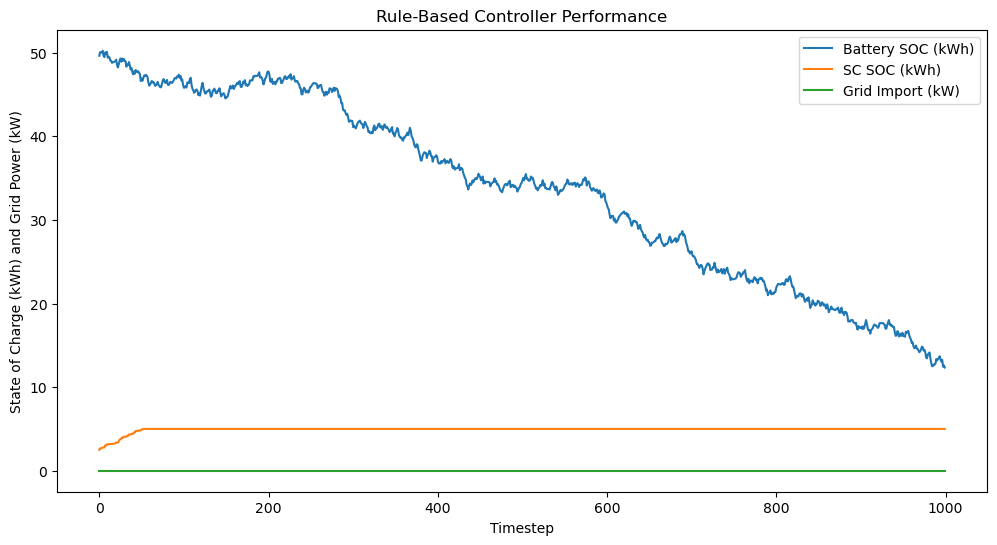

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(rbc_results["Battery_SOC_kWh"], label="Battery SOC (kWh)")
plt.plot(rbc_results["SC_SOC_kWh"], label="SC SOC (kWh)")
plt.plot(rbc_results["Grid_Import_kW"], label="Grid Import (kW)")
plt.legend()
plt.title("Rule-Based Controller Performance")
plt.xlabel("Timestep")
plt.ylabel("State of Charge (kWh) and Grid Power (kW)")
plt.savefig("Rule-Based Controller Performances.png")
plt.show()

# Comparison of the Rule based and the RL model

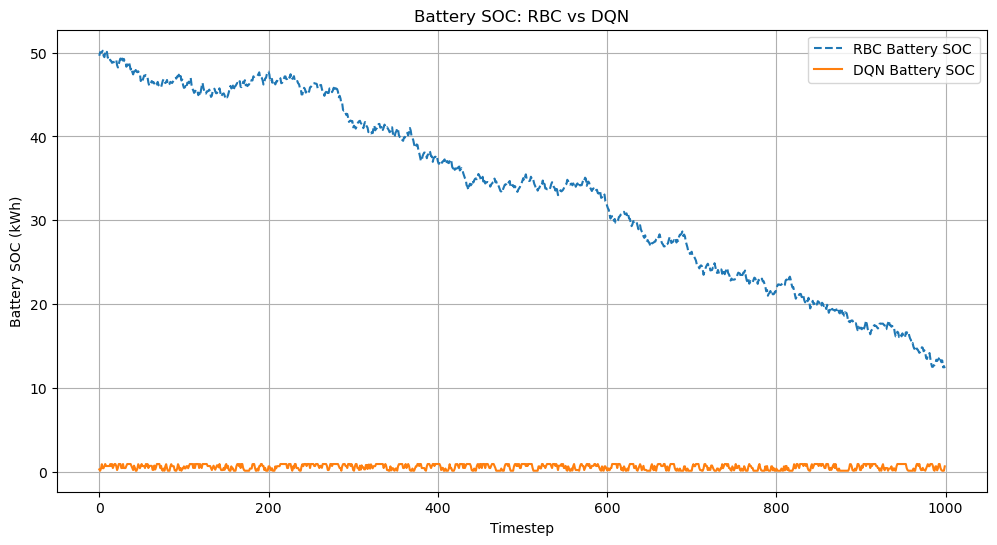

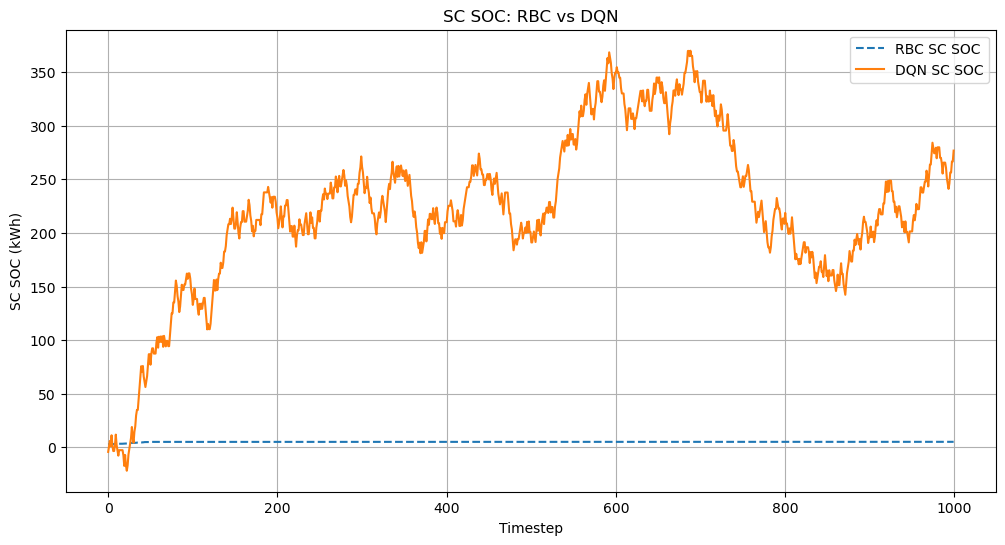

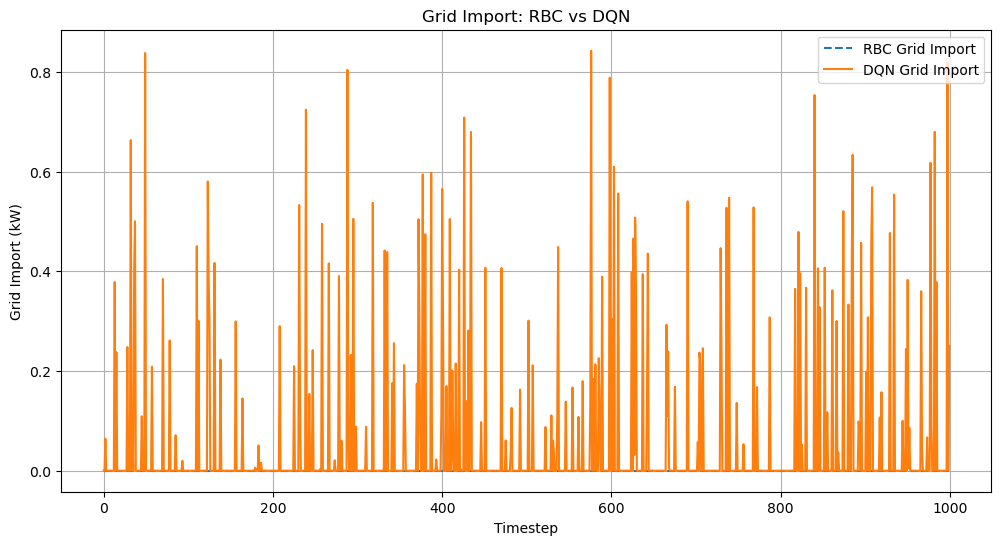

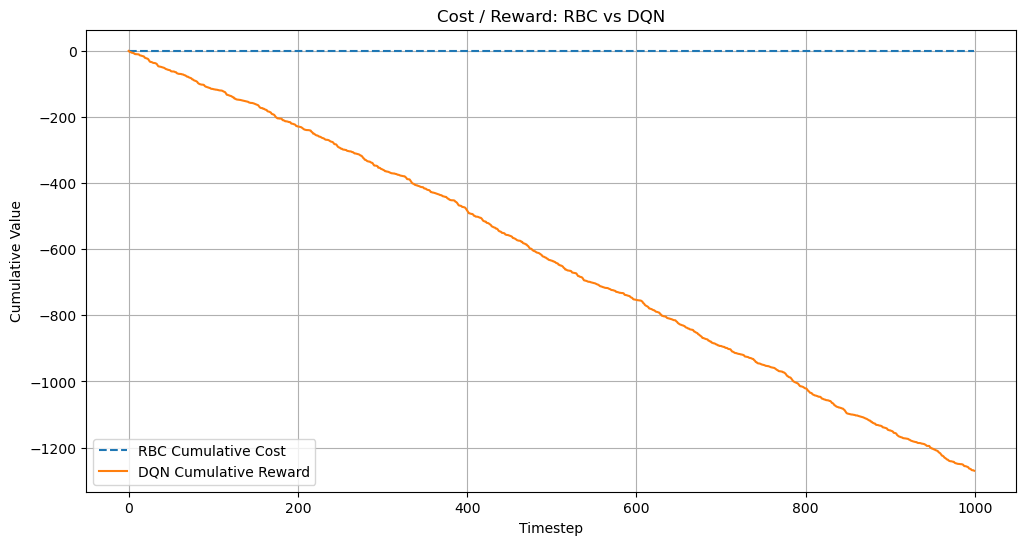

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both results
rbc = pd.read_csv("rul_results.csv")
dqn = pd.read_csv("results_eval/dqn_eval_results.csv")

# Ensure same length for fair comparison
min_len = min(len(rbc), len(dqn))
rbc = rbc.iloc[:min_len]
dqn = dqn.iloc[:min_len]

timesteps = range(min_len)

# 1. Battery SOC comparison
plt.figure(figsize=(12,6))
plt.plot(timesteps, rbc["Battery_SOC_kWh"], label="RBC Battery SOC", linestyle="--")
plt.plot(timesteps, dqn["Battery_SOC_kWh"], label="DQN Battery SOC")
plt.xlabel("Timestep")
plt.ylabel("Battery SOC (kWh)")
plt.title("Battery SOC: RBC vs DQN")
plt.legend()
plt.grid(True)
plt.savefig("comparison_battery_soc.png")
plt.show()

# 2. Supercapacitor SOC comparison
plt.figure(figsize=(12,6))
plt.plot(timesteps, rbc["SC_SOC_kWh"], label="RBC SC SOC", linestyle="--")
plt.plot(timesteps, dqn["SC_SOC_kWh"], label="DQN SC SOC")
plt.xlabel("Timestep")
plt.ylabel("SC SOC (kWh)")
plt.title("SC SOC: RBC vs DQN")
plt.legend()
plt.grid(True)
plt.savefig("comparison_sc_soc.png")
plt.show()

# 3. Grid Import comparison
plt.figure(figsize=(12,6))
plt.plot(timesteps, rbc["Grid_Import_kW"], label="RBC Grid Import", linestyle="--")
plt.plot(timesteps, dqn["Grid_Import_kW"], label="DQN Grid Import")
plt.xlabel("Timestep")
plt.ylabel("Grid Import (kW)")
plt.title("Grid Import: RBC vs DQN")
plt.legend()
plt.grid(True)
plt.savefig("comparison_grid_import.png")
plt.show()

# 4. Cost (or Reward) comparison
plt.figure(figsize=(12,6))
plt.plot(timesteps, rbc["Cost_USD"].cumsum(), label="RBC Cumulative Cost", linestyle="--")
plt.plot(timesteps, dqn["Reward"].cumsum(), label="DQN Cumulative Reward")
plt.xlabel("Timestep")
plt.ylabel("Cumulative Value")
plt.title("Cost / Reward: RBC vs DQN")
plt.legend()
plt.grid(True)
plt.savefig("comparison_cost_reward.png")
plt.show()
